In [1]:
import sys
from pathlib import Path

# Find project root dynamically
PROJECT_ROOT = Path().resolve()

while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.config import *

In [2]:
import pandas as pd

df = pd.read_excel(PROCESSED_DATA_DIR, sheet_name='Sheet1')
print(df.head())

  customer_id  tenure  total_spend  monthly_spend  is_monthly_contract  \
0  3668-QPYBK       2       108.15          53.85                    1   
1  9237-HQITU       2       151.65          70.70                    1   
2  9305-CDSKC       8       820.50          99.65                    1   
3  7892-POOKP      28      3046.05         104.80                    1   
4  0280-XJGEX      49      5036.30         103.70                    1   

   churn_flag  
0           1  
1           1  
2           1  
3           1  
4           1  


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("churn_flag", axis=1)
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Keep only numeric columns
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

In [11]:
import numpy as np

# Replace inf with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill remaining NaNs with median
X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_train.median(), inplace=True)  # use train median


,tenure,total_spend,monthly_spend,is_monthly_contract
2196,72,8468.20,114.05,0
3549,8,908.55,100.15,1
3515,41,3211.20,78.35,0
5162,18,1468.75,78.20,1
4642,72,5919.35,82.65,0
...,...,...,...,...
5660,49,4345.00,87.20,0
5150,28,487.95,20.30,0
4708,5,93.55,20.65,1
5381,56,1051.90,19.70,0


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_proba = log_model.predict_proba(X_test)[:, 1]
print("Logistic Regression AUC:", roc_auc_score(y_test, log_proba))

Logistic Regression AUC: 0.8236934563021521


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:,1]
print("Random Forest AUC:", roc_auc_score(y_test, rf_proba))

Random Forest AUC: 0.7813234648273011


In [15]:
from sklearn.metrics import precision_score, recall_score

threshold = 0.65
preds = (rf_proba > threshold).astype(int)

print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))

Precision: 0.5867346938775511
Recall: 0.3074866310160428


In [16]:
avg_customer_value = 4000
retention_cost = 300

high_risk = preds.sum()
estimated_revenue_saved = high_risk * avg_customer_value

print("Estimated Revenue Protected:", estimated_revenue_saved)

Estimated Revenue Protected: 784000


C:\Users\27677\AppData\Local\Temp\ipykernel_19572\2656733730.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Risk Category", y="Count", data=risk_df, palette=["red", "green"])


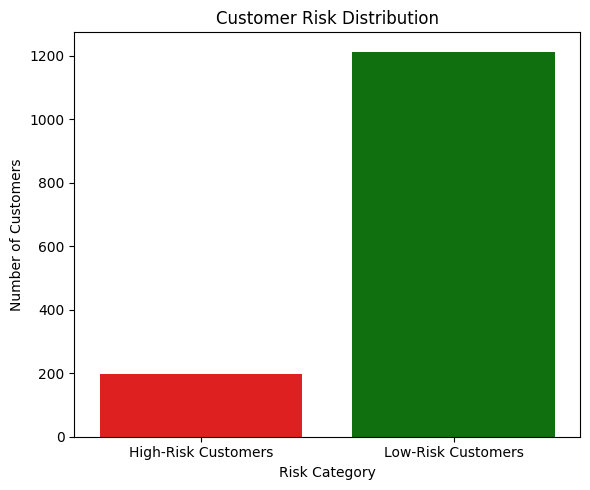

High vs Low Risk Customers chart saved to 'images/high_low_risk_customers.png'


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- High-risk vs total customers ---
total_customers = len(preds)
high_risk = preds.sum()
low_risk = total_customers - high_risk

# Create a simple dataframe for counts
risk_df = pd.DataFrame({
    "Risk Category": ["High-Risk Customers", "Low-Risk Customers"],
    "Count": [high_risk, low_risk]
})

# Plot high vs low risk
plt.figure(figsize=(6,5))
sns.barplot(x="Risk Category", y="Count", data=risk_df, palette=["red", "green"])
plt.title("Customer Risk Distribution")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

print("High vs Low Risk Customers chart saved to 'images/high_low_risk_customers.png'")

C:\Users\27677\AppData\Local\Temp\ipykernel_19572\373137424.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Risk Category", y="Count", data=risk_df, palette=["red", "green"], ax=axes[0])
C:\Users\27677\AppData\Local\Temp\ipykernel_19572\373137424.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Value", data=revenue_df, palette="magma", ax=axes[1])


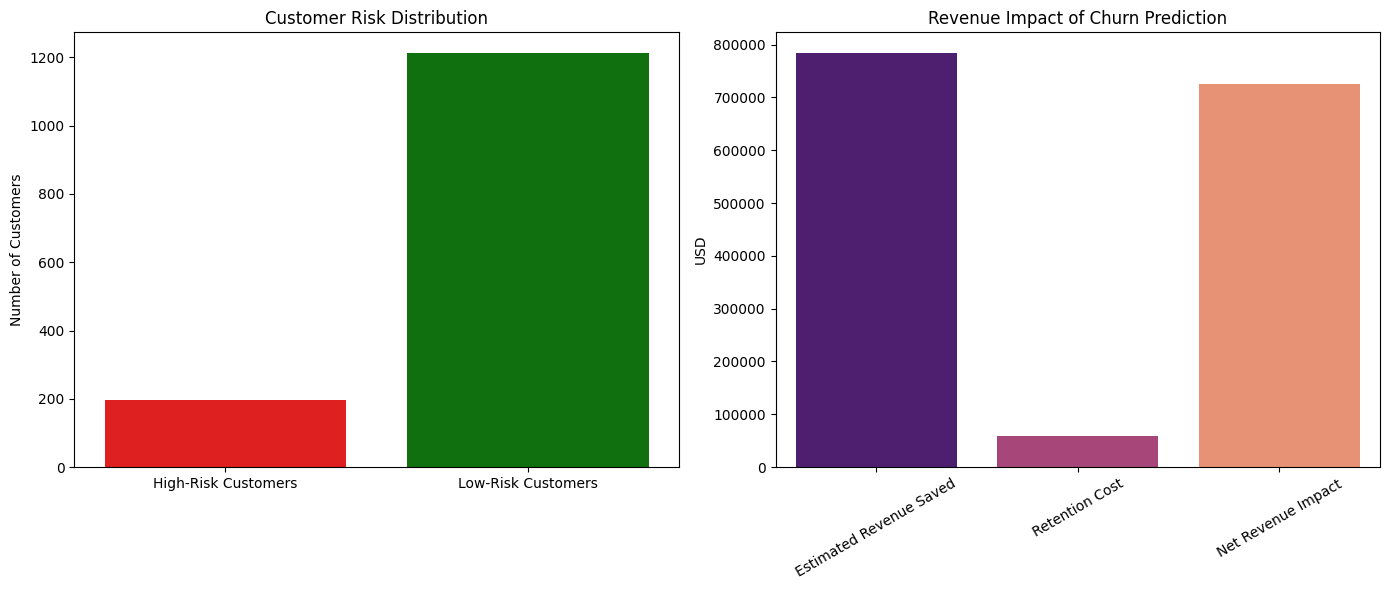

Combined Customer Risk & Revenue Impact chart saved to 'images/customer_risk_revenue_combined.png'


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- High-risk vs Low-risk ---
total_customers = len(preds)
high_risk = preds.sum()
low_risk = total_customers - high_risk

risk_df = pd.DataFrame({
    "Risk Category": ["High-Risk Customers", "Low-Risk Customers"],
    "Count": [high_risk, low_risk]
})

# --- Revenue Impact ---
avg_customer_value = 4000
retention_cost = 300
estimated_revenue_saved = high_risk * avg_customer_value
net_revenue = estimated_revenue_saved - (high_risk * retention_cost)

revenue_df = pd.DataFrame({
    "Category": ["Estimated Revenue Saved", "Retention Cost", "Net Revenue Impact"],
    "Value": [estimated_revenue_saved, high_risk * retention_cost, net_revenue]
})

# --- Combined figure ---
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Left: High vs Low Risk
sns.barplot(x="Risk Category", y="Count", data=risk_df, palette=["red", "green"], ax=axes[0])
axes[0].set_title("Customer Risk Distribution")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("")

# Right: Revenue Impact
sns.barplot(x="Category", y="Value", data=revenue_df, palette="magma", ax=axes[1])
axes[1].set_title("Revenue Impact of Churn Prediction")
axes[1].set_ylabel("USD")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.show()

print("Combined Customer Risk & Revenue Impact chart saved to 'images/customer_risk_revenue_combined.png'")

C:\Users\27677\AppData\Local\Temp\ipykernel_19572\1373630983.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")


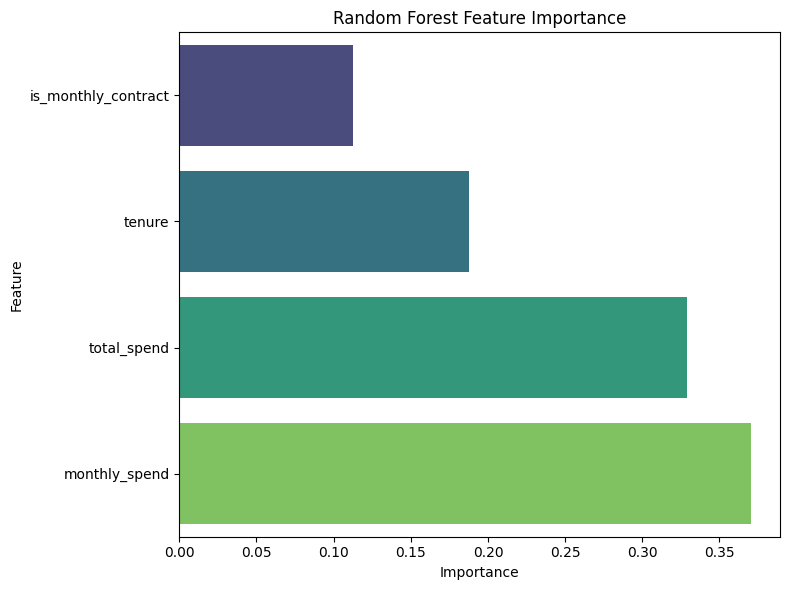

Random Forest Feature Importance chart saved to 'images/feature_importance_chart.png'


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Random Forest Feature Importance ---
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=True)  # ascending=True for horizontal bar

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

print("Random Forest Feature Importance chart saved to 'images/feature_importance_chart.png'")